# Diffusion Models

## 🚀 What Makes Diffusion Models Special?

Diffusion models are the technology behind:
- **Stable Diffusion** (free, open-source image generation)
- **OpenAI** (OpenAI's text-to-image)
- **Midjourney** (artistic image generation)
- **Adobe Firefly** (integrated into Creative Suite)
- **Google Imagen** (photorealistic generation)

They've democratized AI art creation and made high-quality image generation accessible to everyone!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

## What is a Diffusion Model? 🎨

### The Simple Explanation

Imagine you have a beautiful painting, and you gradually add noise to it until it becomes pure random static. A diffusion model learns to **reverse this process** - it starts with noise and gradually removes it to create a beautiful image.

### Real-World Analogy: Sculpting from Marble

Think of diffusion models like **Michelangelo sculpting David**:
- **Marble block** = Random noise
- **Chiseling away** = Removing noise step by step
- **Final sculpture** = Generated image

But instead of chiseling, the AI "denoises" pixel by pixel!

### The Two-Step Process:

1. **Forward Process (Noising)**:
   - Take real images from training data
   - Gradually add noise over 1000 steps
   - Until they become pure random noise
   - Like watching a photograph fade in sunlight

2. **Reverse Process (Denoising)**:
   - Start with pure noise
   - AI predicts what noise to remove at each step
   - After 1000 steps: Beautiful, coherent image!
   - Like developing a photograph in a darkroom

### Why This Works Better Than GANs

**GANs**: Two networks fighting each other (unstable)
**Diffusion**: One network learning to clean up noise (stable)

It's like the difference between:
- **GANs**: Learning to paint while someone criticizes every brushstroke
- **Diffusion**: Learning to restore old photographs step by step

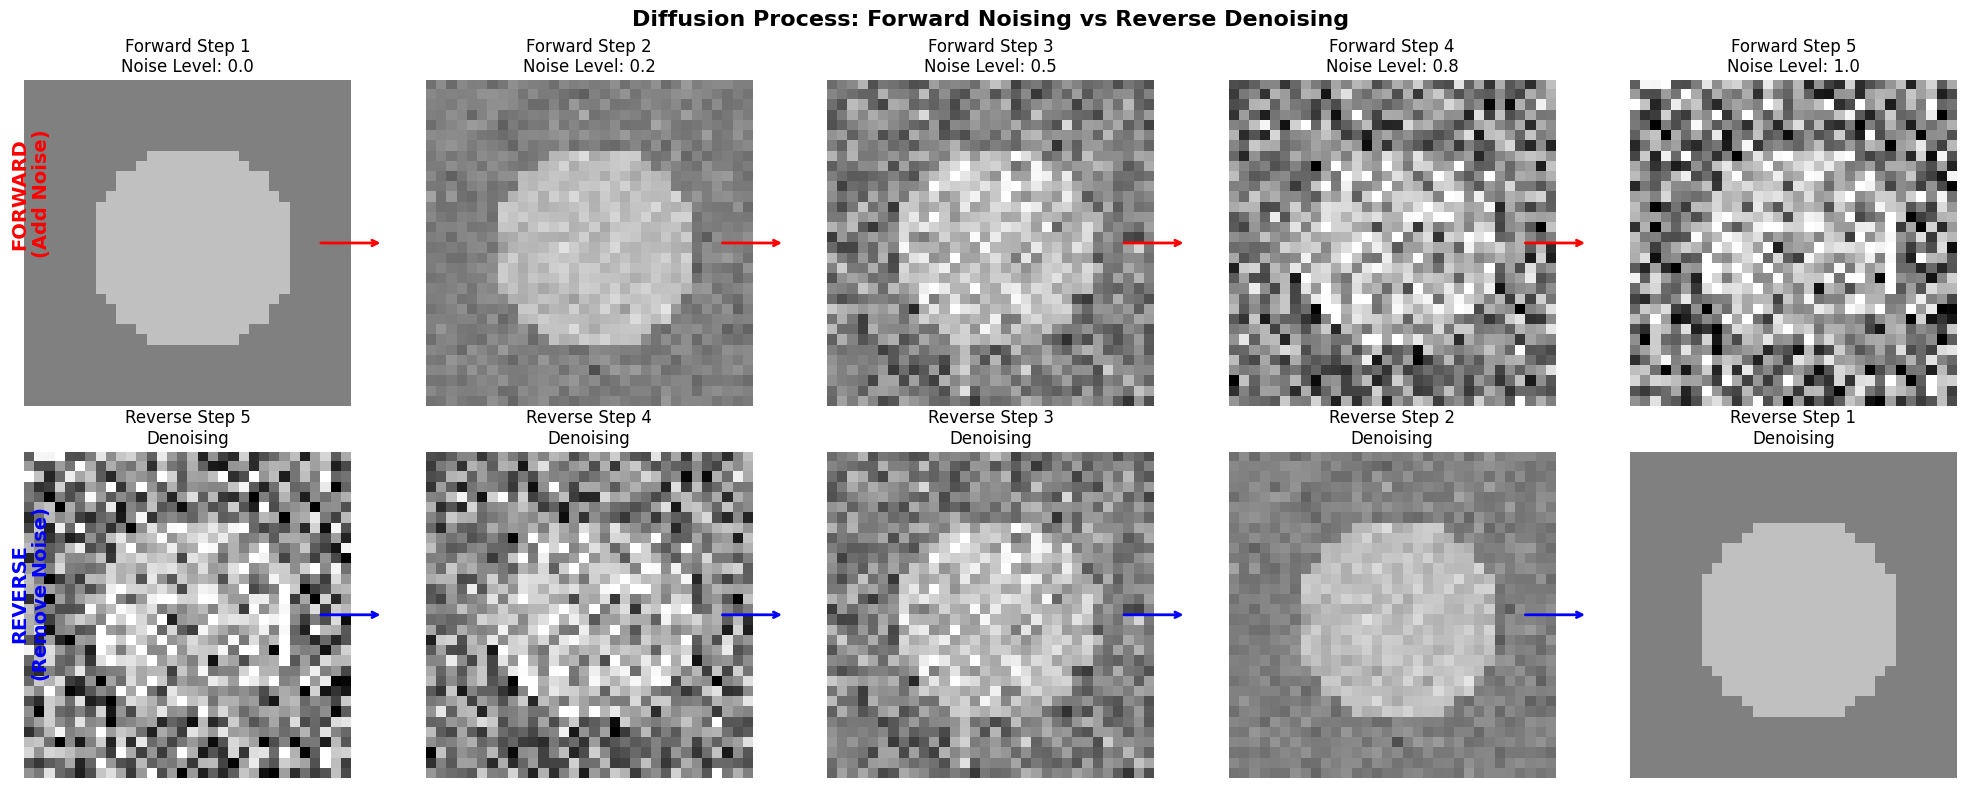

In [2]:
def visualize_diffusion_process():
    """
    Visualize the forward and reverse diffusion process.
    """
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))

    # Create a simple "image" (circle)
    original_image = torch.zeros(1, 1, 32, 32)
    y, x = torch.meshgrid(torch.arange(32), torch.arange(32), indexing='ij')
    mask = (x - 16)**2 + (y - 16)**2 < 100
    original_image[0, 0][mask] = 1.0

    # Forward process: add noise gradually
    noise_levels = [0, 0.2, 0.5, 0.8, 1.0]

    for i, noise_level in enumerate(noise_levels):
        # Add noise
        noise = torch.randn_like(original_image) * noise_level
        noisy_image = original_image + noise
        noisy_image = torch.clamp(noisy_image, -2, 2)

        # Forward process
        axes[0, i].imshow(noisy_image[0, 0], cmap='gray', vmin=-2, vmax=2)
        axes[0, i].set_title(f'Forward Step {i+1}\nNoise Level: {noise_level:.1f}')
        axes[0, i].axis('off')

        # Reverse process (conceptual)
        reverse_idx = 4 - i
        axes[1, reverse_idx].imshow(noisy_image[0, 0], cmap='gray', vmin=-2, vmax=2)
        axes[1, reverse_idx].set_title(f'Reverse Step {i+1}\nDenoising')
        axes[1, reverse_idx].axis('off')

    # Add arrows
    for i in range(4):
        axes[0, i].annotate('', xy=(1.1, 0.5), xytext=(0.9, 0.5),
                          xycoords='axes fraction', textcoords='axes fraction',
                          arrowprops=dict(arrowstyle='->', lw=2, color='red'))

        axes[1, i].annotate('', xy=(1.1, 0.5), xytext=(0.9, 0.5),
                          xycoords='axes fraction', textcoords='axes fraction',
                          arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

    # Labels
    fig.text(0.02, 0.75, 'FORWARD\n(Add Noise)', fontsize=14, fontweight='bold',
             color='red', rotation=90, ha='center', va='center')
    fig.text(0.02, 0.25, 'REVERSE\n(Remove Noise)', fontsize=14, fontweight='bold',
             color='blue', rotation=90, ha='center', va='center')

    plt.suptitle('Diffusion Process: Forward Noising vs Reverse Denoising',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_diffusion_process()

## 🌟 Real Diffusion Models You Can Use Today

Let's explore the most popular diffusion models and see how to use them in practice!

### 1. **Stable Diffusion** 🎨
**What it is**: Open-source text-to-image model
**Best for**: General image generation, art creation, free commercial use
**Hardware**: Runs on consumer GPUs

### 2. **OpenI** 🤖
**What it is**: OpenAI's commercial text-to-image service
**Best for**: Photorealistic images, creative combinations
**Access**: Pay-per-use API or web interface

**Strengths**:
- Exceptional prompt understanding
- Photorealistic human faces
- Creative concept combinations
- Inpainting (editing parts of images)

### 3. **Midjourney** 🎭
**What it is**: Artistic-focused diffusion model
**Best for**: Stylized art, fantasy, concept art
**Access**: Discord bot subscription or via web

**Famous for**:
- Dreamy, artistic style
- Fantasy and sci-fi imagery
- Award-winning AI art competitions

### 4. **Adobe Firefly** 🔥
**What it is**: Commercial-safe diffusion model
**Best for**: Professional design work
**Access**: Adobe Creative Cloud integration

**Key features**:
- Trained only on licensed content
- Safe for commercial use
- Integrated into Photoshop

### 5. **Google Imagen** 📸
**What it is**: Research model focused on photorealism
**Best for**: Ultra-realistic image generation
**Access**: Via google gemini

**Achievements**:
- State-of-the-art photorealism
- Excellent text rendering in images
- Advanced prompt understanding

## 🛠️ Practical Applications & Use Cases

### **Creative Industries**
- **Game Development**: Concept art, textures, character designs
- **Film & Animation**: Storyboards, background art, creature design
- **Publishing**: Book covers, illustrations, magazine imagery
- **Advertising**: Product mockups, campaign visuals, social media content

### **Business Applications**
- **E-commerce**: Product photos, lifestyle imagery
- **Real Estate**: Virtual staging, architectural visualization
- **Education**: Custom illustrations for textbooks and presentations
- **Healthcare**: Medical illustration, patient education materials

### **Personal Projects**
- **Art Creation**: Personal artwork, gifts, decorations
- **Content Creation**: YouTube thumbnails, blog images
- **Social Media**: Custom posts, profile pictures
- **Learning**: Exploring creativity, understanding AI

### **Research & Development**
- **Data Augmentation**: Creating training data for other AI models
- **Prototyping**: Quick visual mockups for ideas
- **Simulation**: Generating synthetic datasets
- **Art Studies**: Exploring artistic styles and techniques

## Why Diffusion Models Are Better Than GANs

Diffusion models solve many of the problems that made GANs difficult to work with:

### ✅ **More Stable Training**
- No adversarial training - just simple noise prediction
- Consistent gradients throughout training
- Less likely to collapse or fail

### ✅ **Higher Quality Results**
- Generate more realistic and detailed images
- Better fine details and coherent structures
- Can generate very high-resolution images

### ✅ **Better Mode Coverage**
- No mode collapse - explores the full data distribution
- Generates diverse outputs consistently

### ✅ **Controllable Generation**
- Can control the generation process at different steps
- Easy to add conditioning (text, class labels, etc.)
- Gradual refinement allows for fine control